<a href="https://www.kaggle.com/code/sonawanelalitsunil/2025-state-employee-salary-ml-45?scriptVersionId=249554255" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2025-state-employee-pay/2025_State_Employee_Pay.csv


## Title:
📊 2025 U.S. State Employee Salaries Overview



## Detailed Description:
This dataset provides a comprehensive view of state employee salaries for the year 2025 across various government agencies. It includes information on:

Calendar Year – Year of salary data (2025)

Agency Name – Name of the government department or agency employing the individual

Position Title – Official job title of the employee

Employee Name – Full name of the state employee

YTD Gross Pay – Total gross pay received year-to-date (pre-tax and deductions)

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/2025-state-employee-pay/2025_State_Employee_Pay.csv')

In [3]:
df.head()

,Calendar Year,Agency Name,Position Title,Employee Name,YTD Gross Pay
0,2025,AGRICULTURE,ACCOUNTANT,"OTTO, BRIDGET",30000.00
1,2025,AGRICULTURE,ACCOUNTS SUPERVISOR,"STOEHR, KALEB J.",32091.12
2,2025,AGRICULTURE,ADMIN SUPPORT ASSISTANT,"BROWN, LISA RENEE",18507.60
3,2025,AGRICULTURE,ADMIN SUPPORT ASSISTANT,"COLE, SHELBI R",8897.82
4,2025,AGRICULTURE,ADMIN SUPPORT ASSISTANT,"GOFF, AMANDA K.",16312.67


In [4]:
df.tail()

,Calendar Year,Agency Name,Position Title,Employee Name,YTD Gross Pay
62845,2025,TRANSPORTATION,TRANSPORTATION PROJECT MGR,"WHITE, JACLYN ANN",51936.48
62846,2025,TRANSPORTATION,TRANSPORTATION PROJECT MGR,"WOOLSEY, CURT D",47999.76
62847,2025,TRANSPORTATION,URBAN TRAFFIC SUPERVISOR,"DOTSON, JOSEPH L",37901.67
62848,2025,TRANSPORTATION,URBAN TRAFFIC SUPERVISOR,"HENSON, JAMES DUSTIN",43877.86
62849,2025,TRANSPORTATION,URBAN TRAFFIC SUPERVISOR,"TINKER, JESSE ROBERT",41389.35


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62850 entries, 0 to 62849
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Calendar Year   62850 non-null  int64  
 1   Agency Name     62850 non-null  object 
 2   Position Title  62850 non-null  object 
 3   Employee Name   62850 non-null  object 
 4   YTD Gross Pay   62850 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.4+ MB


In [6]:
df.describe()

,Calendar Year,YTD Gross Pay
count,62850.0,62850.000000
mean,2025.0,22921.102404
std,0.0,15505.241337
min,2025.0,-1093.810000
25%,2025.0,12394.527500
50%,2025.0,22687.595000
75%,2025.0,29846.400000
max,2025.0,831677.320000


In [7]:
df.isnull().sum()

Calendar Year     0
Agency Name       0
Position Title    0
Employee Name     0
YTD Gross Pay     0
dtype: int64

In [8]:
df.duplicated().sum()

2

In [9]:
df.shape

(62850, 5)

In [10]:
df.dtypes

Calendar Year       int64
Agency Name        object
Position Title     object
Employee Name      object
YTD Gross Pay     float64
dtype: object

In [11]:
df.columns

Index(['Calendar Year', 'Agency Name', 'Position Title', 'Employee Name',
       'YTD Gross Pay'],
      dtype='object')

## Data visualizations

In [12]:
# Remove any missing or invalid entries in YTD Gross Pay
df['YTD Gross Pay'] = pd.to_numeric(df['YTD Gross Pay'], errors='coerce')
df.dropna(subset=['YTD Gross Pay'], inplace=True)

# Optional: Clean whitespace
df['Agency Name'] = df['Agency Name'].str.strip()
df['Position Title'] = df['Position Title'].str.strip()
df['Employee Name'] = df['Employee Name'].str.strip()


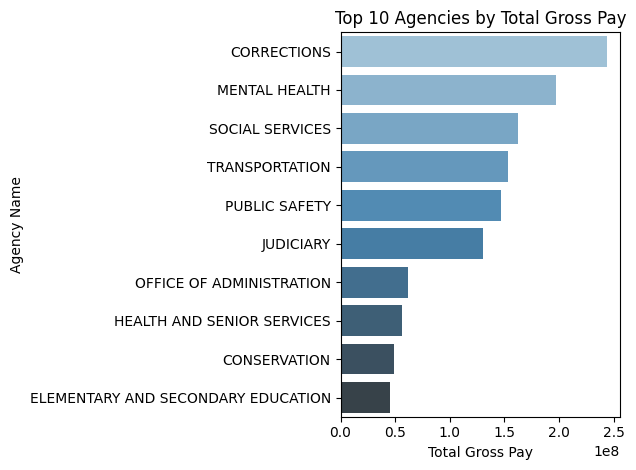

In [13]:
top_agencies = df.groupby('Agency Name')['YTD Gross Pay'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_agencies.values, y=top_agencies.index, palette='Blues_d')
plt.title("Top 10 Agencies by Total Gross Pay")
plt.xlabel("Total Gross Pay")
plt.ylabel("Agency Name")
plt.tight_layout()
plt.show()


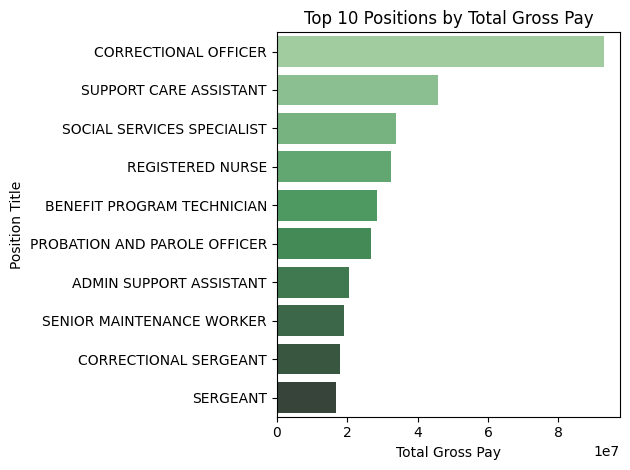

In [14]:
top_positions = df.groupby('Position Title')['YTD Gross Pay'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_positions.values, y=top_positions.index, palette='Greens_d')
plt.title("Top 10 Positions by Total Gross Pay")
plt.xlabel("Total Gross Pay")
plt.ylabel("Position Title")
plt.tight_layout()
plt.show()


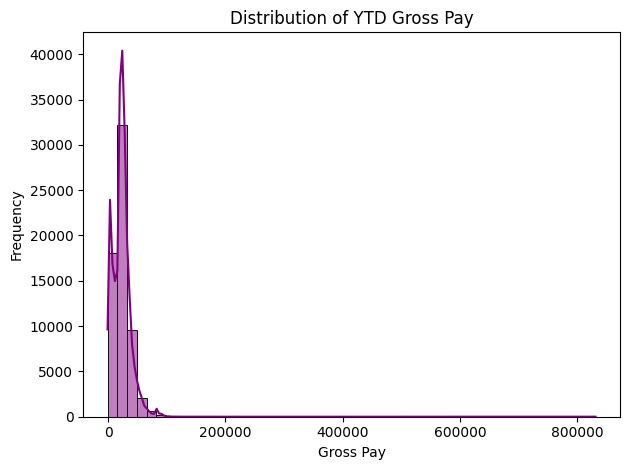

In [15]:
sns.histplot(df['YTD Gross Pay'], bins=50, kde=True, color='purple')
plt.title("Distribution of YTD Gross Pay")
plt.xlabel("Gross Pay")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


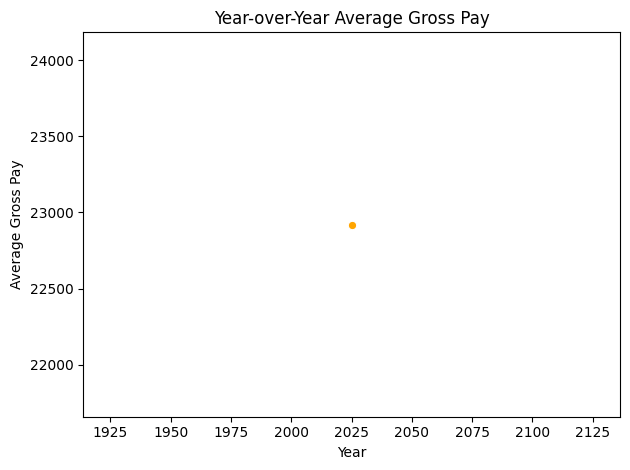

In [16]:
avg_by_year = df.groupby('Calendar Year')['YTD Gross Pay'].mean()

sns.lineplot(x=avg_by_year.index, y=avg_by_year.values, marker='o', color='orange')
plt.title("Year-over-Year Average Gross Pay")
plt.xlabel("Year")
plt.ylabel("Average Gross Pay")
plt.tight_layout()
plt.show()


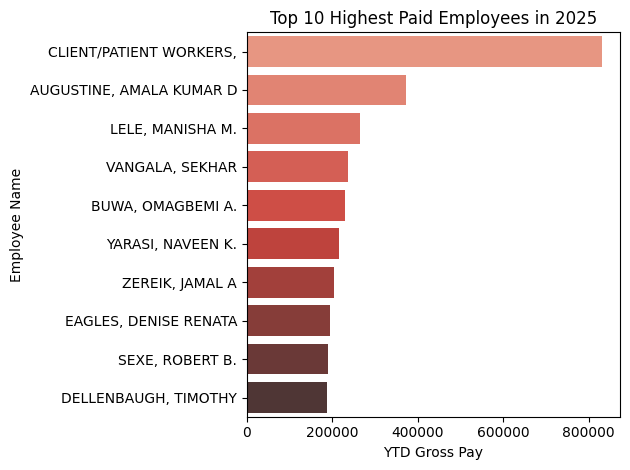

In [17]:
latest_year = df['Calendar Year'].max()
latest_df = df[df['Calendar Year'] == latest_year]

top_employees = latest_df[['Employee Name', 'YTD Gross Pay']].sort_values(by='YTD Gross Pay', ascending=False).head(10)

sns.barplot(x='YTD Gross Pay', y='Employee Name', data=top_employees, palette='Reds_d')
plt.title(f"Top 10 Highest Paid Employees in {latest_year}")
plt.xlabel("YTD Gross Pay")
plt.ylabel("Employee Name")
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Regressors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [19]:
# Clean numeric column
df['YTD Gross Pay'] = pd.to_numeric(df['YTD Gross Pay'], errors='coerce')

# Drop missing
df.dropna(subset=['YTD Gross Pay'], inplace=True)

# Strip strings
for col in ['Agency Name', 'Position Title', 'Employee Name']:
    df[col] = df[col].astype(str).str.strip()

In [20]:
label_encoders = {}
for col in ['Agency Name', 'Position Title', 'Employee Name']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [21]:
# Features and target
X = df[['Calendar Year', 'Agency Name', 'Position Title', 'Employee Name']]
y = df['YTD Gross Pay']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MSE': mse, 'R2 Score': r2})


In [23]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='R2 Score', ascending=False, inplace=True)
print(results_df)


                      Model           MSE  R2 Score
1             Random Forest  1.287328e+08  0.462718
5         Gradient Boosting  1.619264e+08  0.324180
0         Linear Regression  2.390142e+08  0.002444
3  Support Vector Regressor  2.396504e+08 -0.000211
4             KNN Regressor  2.596453e+08 -0.083662
2             Decision Tree  2.772373e+08 -0.157085


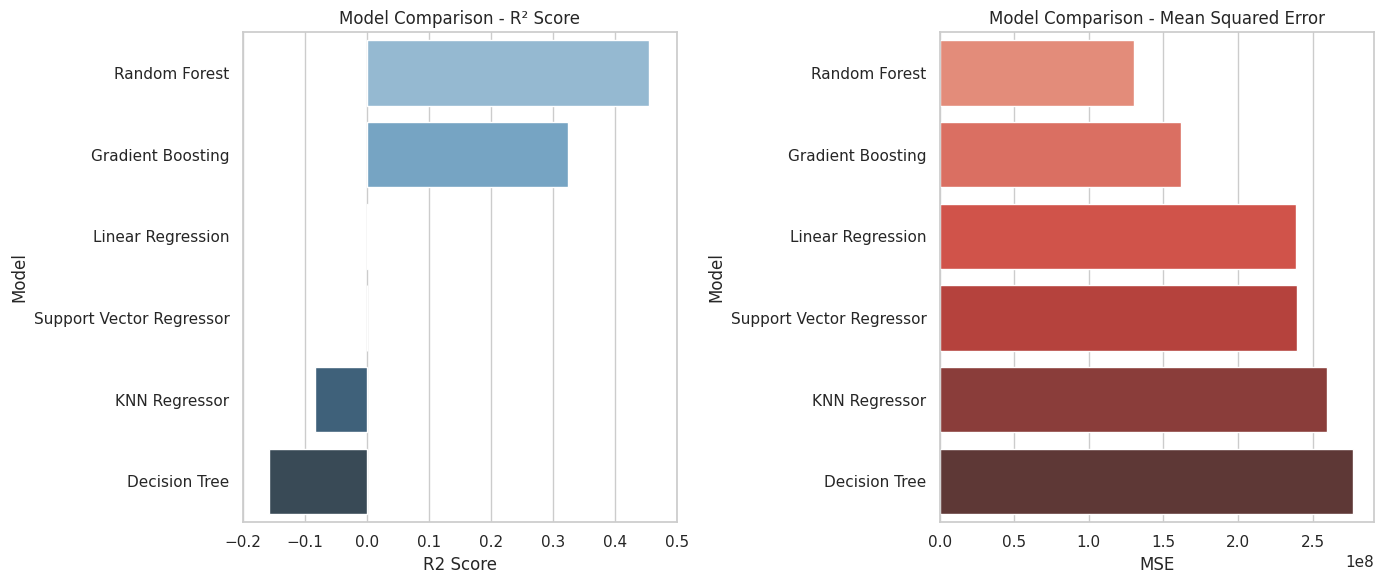

In [24]:
results_df = pd.DataFrame({
    'Model': [
        'Random Forest', 'Gradient Boosting', 'Linear Regression',
        'Support Vector Regressor', 'KNN Regressor', 'Decision Tree'
    ],
    'MSE': [
        1.305457e+08, 1.618310e+08, 2.390142e+08,
        2.396504e+08, 2.596453e+08, 2.772868e+08
    ],
    'R2 Score': [
        0.455151, 0.324578, 0.002444,
        -0.000211, -0.083662, -0.157292
    ]
})

# Set seaborn style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Barplot for R2 Score
plt.subplot(1, 2, 1)
sns.barplot(x='R2 Score', y='Model', data=results_df, palette='Blues_d')
plt.title("Model Comparison - R² Score")
plt.xlim(-0.2, 0.5)

# Barplot for MSE
plt.subplot(1, 2, 2)
sns.barplot(x='MSE', y='Model', data=results_df, palette='Reds_d')
plt.title("Model Comparison - Mean Squared Error")

plt.tight_layout()
plt.show()


## Thank you...pls upvote!!!